In [1]:
import pandas as pd
import numpy as np
from scipy import stats

In [18]:
PATH = '/content/full_companies_dataset.xlsx'
N_SIMULATIONS = 100_000 #for Monte Carlo
SEED = 42. # ensures reproduciability with same p-values

df = pd.read_excel(PATH, sheet_name='full_companies_dataset')

SIZE_ORDER = ['Very Large', 'Large', 'Mid-Size', 'Small']


In [7]:
#build contingency table and run MC simulations

def run_fisher_mc(predictor_series, outcome_series, label):

    # pd.crosstab counts how many observations fall into each combination of
    # predictor and outcome. The result is a 2D table with predictor categories
    # as rows and outcome categories as columns.

  table = pd.crosstab(predictor_series, outcome_series)

  table = table.reindex(index=SIZE_ORDER, columns=[False, True])
  table.columns = ['No', 'Yes']

  #convert pandas table to a plain numpy array of counts

  obs = table.values

  print("=" * 60)
  print(label)
  print("=" * 60)
  print()
  print("Observed contingency table:")
  print(table.to_string())
  print()

  #compute chi-square statistic and asymptotic p-value

  # Total sample size and table dimensions
  n = obs.sum()
  r, c = obs.shape

  #marginal rows and columns total
  row_sums = obs.sum(axis=1)
  col_sums = obs.sum(axis=0)

  #expected count for each cell, assuming the two variables are independent
  #the formula  E_ij = (row_i_total * col_j_total) / N from probability means:
  #if independent P(row=i and col=j) = P(row=i) * P(col=j).
  #np.outer computes all pairwise products of row_sums and col_sums.
  expected = np.outer(row_sums, col_sums) / n

  #chi-square statistic -- sum over all cells of(observed - expected)^2/expected.
  #this measures how far the observed table is from the expected under-the null table

  chi2_obs = ((obs - expected) ** 2 / expected).sum()

  #degress of freedom
  dof = (r - 1) * (c - 1)

  #convert chi-square statistic to a pvalue from the distribution

  p_chi = 1 - stats.chi2.cdf(chi2_obs, dof)

  #cohrans rule check: If more than 20% of cells are below 5,
  #the chi-square approximation is unreliable.

  n_below_5 = (expected < 5).sum()
  pct_below_5 = n_below_5 / expected.size * 100

  # Print the chi-square results.
  print(f"N:                         {n}")
  print(f"Chi-square statistic:      {chi2_obs:.3f}")
  print(f"Degrees of freedom:        {dof}")
  print(f"Chi-square p (asymptotic): {p_chi:.4f}  "
          f"[{n_below_5}/{expected.size} cells with expected <5, {pct_below_5:.0f}%]")
  print()

  #monte carlo --fishers exact test
  #when the table has more than 2 rows, we must simulate many random tables that
  #share the same marginal totals as the observed table, compute chi-square
  #statistics for all of them, report the fraction of simulated statistics

  print(f"Running Monte Carlo Fisher's exact ({N_SIMULATIONS:,} permutations, seed={SEED})...")

  rng = np.random.default_rng(SEED)

  #construct a deck of row labels and column labels so that when matched up it
  #reproduces the observed marginal totals

  row_labels = np.repeat(np.arange(r), row_sums)
  col_template = np.repeat(np.arange(c), col_sums)

  #counter for tables with chi-square statistic at least as extreme as the one observed

  extreme = 0

  #simulation loop

  for _ in range(N_SIMULATIONS):

    permuted_cols = rng.permutation(col_template)
    sim = np.zeros((r, c), dtype=int)
    np.add.at(sim, (row_labels, permuted_cols), 1)

    chi2_sim = ((sim - expected) ** 2 / expected).sum()

    if chi2_sim >= chi2_obs:
            extreme += 1

   # we add one in numerator and denominator to prevent p-value from being exactly 0
  p_fisher = (extreme + 1) / (N_SIMULATIONS + 1)

   #cramer's v as an effect size measure

  V = np.sqrt(chi2_obs / (n * min(r - 1, c - 1)))
  if V < 0.1:
      interp = "negligible"
  elif V < 0.3:
      interp = "small"
  elif V < 0.5:
      interp = "medium"
  else:
      interp = "large"

     # Print the Fisher's exact results and the effect size.
  print()
  print(f"Fisher's exact (Monte Carlo):")
  print(f"  p-value:                 {p_fisher:.4f}")
  print(f"Cramér's V:                {V:.3f}  [{interp}]")
  print()

# Run 1: size × confirmed_pricing on full sample
run_fisher_mc(
    df['size_bucket'], df['confirmed_pricing'],
    "RUN 1 — SIZE (4 LEVELS) × USES AP")

# Run 2: size × disclosure on AP users only
ap_users = df[df['confirmed_pricing']]
run_fisher_mc(
    ap_users['size_bucket'], ap_users['disclosure'],
    "RUN 2 — SIZE (4 LEVELS) × DISCLOSURE (AP users only)")



RUN 1 — SIZE (4 LEVELS) × USES AP

Observed contingency table:
             No  Yes
size_bucket         
Very Large   23   18
Large         8    6
Mid-Size     10    5
Small         6    1

N:                         77
Chi-square statistic:      2.502
Degrees of freedom:        3
Chi-square p (asymptotic): 0.4749  [2/8 cells with expected <5, 25%]

Running Monte Carlo Fisher's exact (100,000 permutations, seed=42)...

Fisher's exact (Monte Carlo):
  p-value:                 0.4892
Cramér's V:                0.180  [small]

RUN 2 — SIZE (4 LEVELS) × DISCLOSURE (AP users only)

Observed contingency table:
             No  Yes
size_bucket         
Very Large    9    9
Large         4    2
Mid-Size      4    1
Small         1    0

N:                         30
Chi-square statistic:      2.361
Degrees of freedom:        3
Chi-square p (asymptotic): 0.5009  [6/8 cells with expected <5, 75%]

Running Monte Carlo Fisher's exact (100,000 permutations, seed=42)...

Fisher's exact (Monte Carlo)

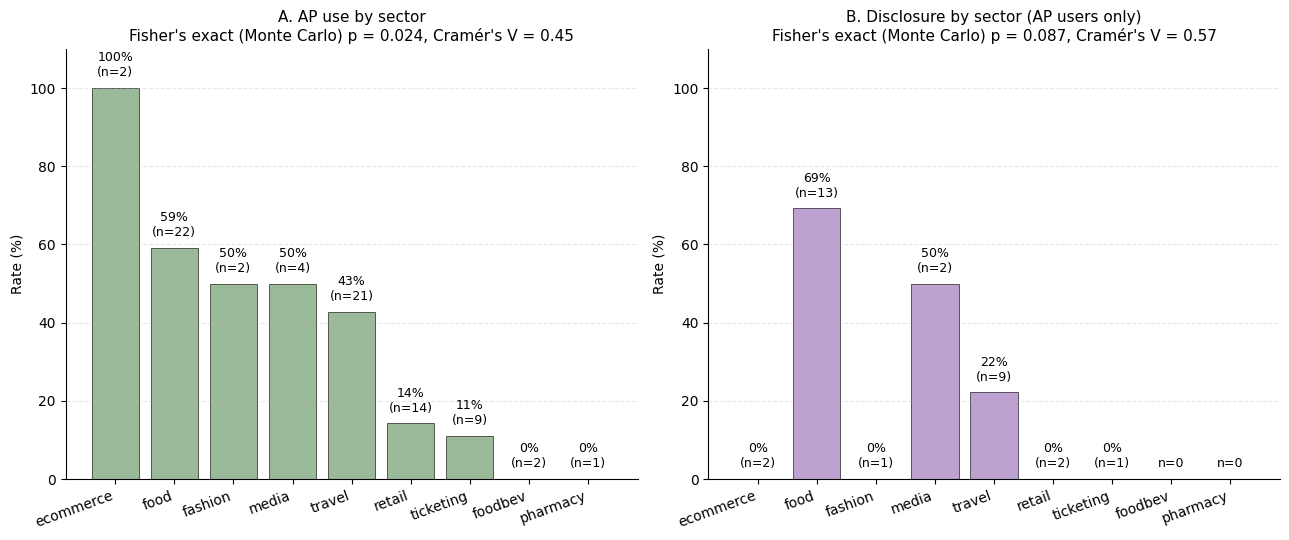

Saved /content/figure1_sector_two_stage.png


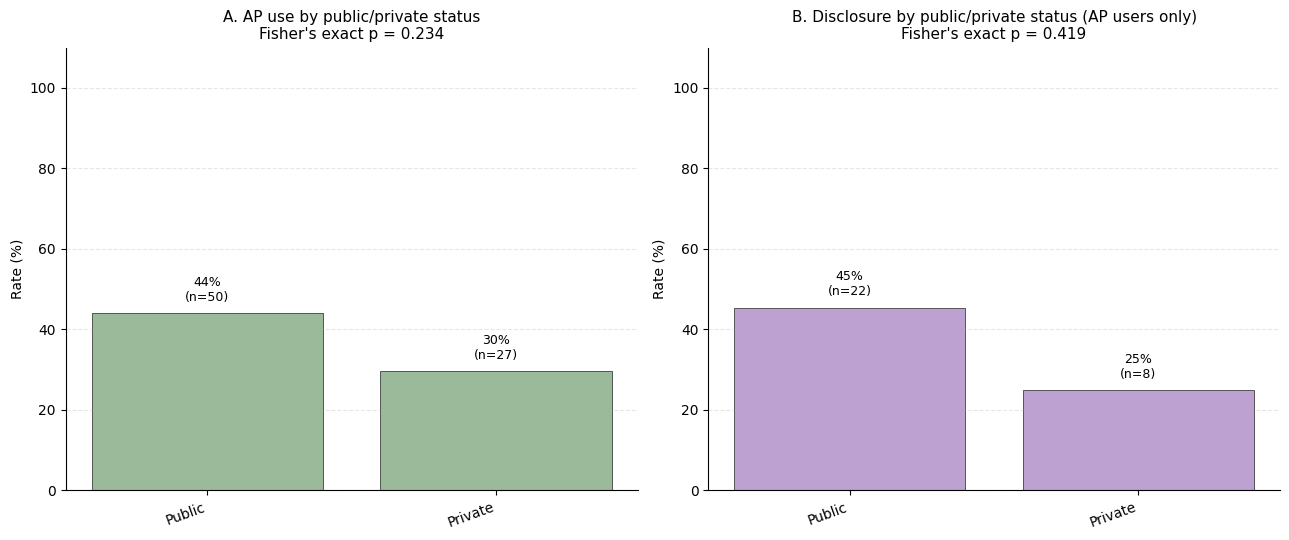

Saved /content/figure2_pubpriv_two_stage.png


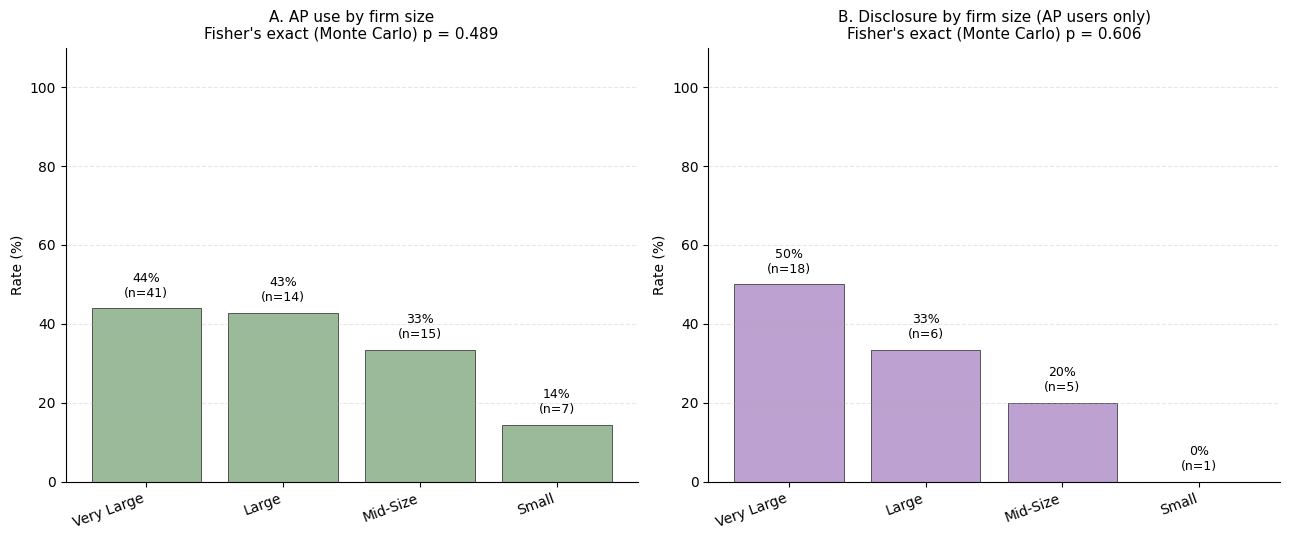

Saved /content/figure3_size_two_stage.png


In [19]:
#figures script

import matplotlib.pyplot as plt
# Cast booleans to readable category labels for plotting
df['public_label'] = np.where(df['public'], 'Public', 'Private')

ADOPT_COLOR = '#8AAE88'
DISCLOSE_COLOR = '#B291C9'


def rates_by_group(panel, group_col, outcome_col, group_order=None):

    rows = []
    groups = group_order if group_order else sorted(panel[group_col].dropna().unique())
    for g in groups:
        sub = panel[panel[group_col] == g]
        n = len(sub)
        if n == 0:
            rows.append({'group': g, 'n': 0, 'rate': 0})
            continue
        succ = sub[outcome_col].sum()
        rate = succ / n
        rows.append({'group': g, 'n': n, 'rate': rate})
    return pd.DataFrame(rows)


def plot_two_stage(predictor, group_order, title_prefix,
                   adoption_subtitle, disclosure_subtitle, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    # Panel A: adoption (full sample)
    data_a = rates_by_group(df, predictor, 'confirmed_pricing', group_order)

    # Panel B: disclosure among AP users
    ap_users = df[df['confirmed_pricing']]
    data_b = rates_by_group(ap_users, predictor, 'disclosure', group_order)

    for ax, data, color, panel_title in [
        (axes[0], data_a, ADOPT_COLOR, f'A. AP use by {title_prefix}\n{adoption_subtitle}'),
        (axes[1], data_b, DISCLOSE_COLOR, f'B. Disclosure by {title_prefix} (AP users only)\n{disclosure_subtitle}'),
    ]:
        x = np.arange(len(data))
        ax.bar(x, data['rate'] * 100, color=color, alpha=0.85,
               edgecolor='black', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(data['group'], rotation=20, ha='right')
        ax.set_ylabel('Rate (%)')
        ax.set_title(panel_title, fontsize=11)
        ax.set_ylim(0, 110)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        for i, row in data.iterrows():
            label = f"{row['rate']*100:.0f}%\n(n={row['n']})" if row['n'] > 0 else "n=0"
            ax.text(i, max(row['rate']*100, 0) + 3, label,
                    ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {out_path}")


    # Figure 1 — Sector (9 levels, ordered by AP adoption rate descending)
sector_order = ['ecommerce', 'food', 'fashion', 'media', 'travel',
                'retail', 'ticketing', 'foodbev', 'pharmacy']
plot_two_stage(
    'sector', sector_order, 'sector',
    "Fisher's exact (Monte Carlo) p = 0.024, Cramér's V = 0.45",
    "Fisher's exact (Monte Carlo) p = 0.087, Cramér's V = 0.57",
    '/content/figure1_sector_two_stage.png',
)

# Figure 2 — Public/Private (binary)
plot_two_stage(
    'public_label', ['Public', 'Private'], 'public/private status',
    "Fisher's exact p = 0.234",
    "Fisher's exact p = 0.419",
    '/content/figure2_pubpriv_two_stage.png',
)

# Figure 3 — Size (4 levels, ordered largest to smallest)
plot_two_stage(
    'size_bucket', ['Very Large', 'Large', 'Mid-Size', 'Small'], 'firm size',
    "Fisher's exact (Monte Carlo) p = 0.489",
    "Fisher's exact (Monte Carlo) p = 0.606",
    '/content/figure3_size_two_stage.png',
)

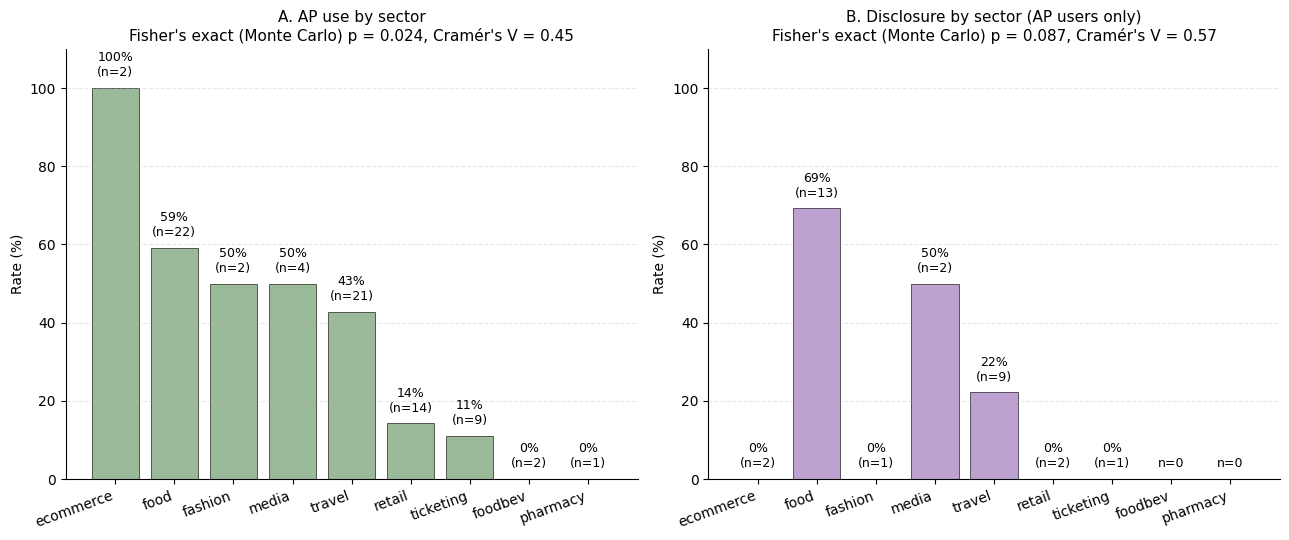

Saved /content/figure1_sector_two_stage.png


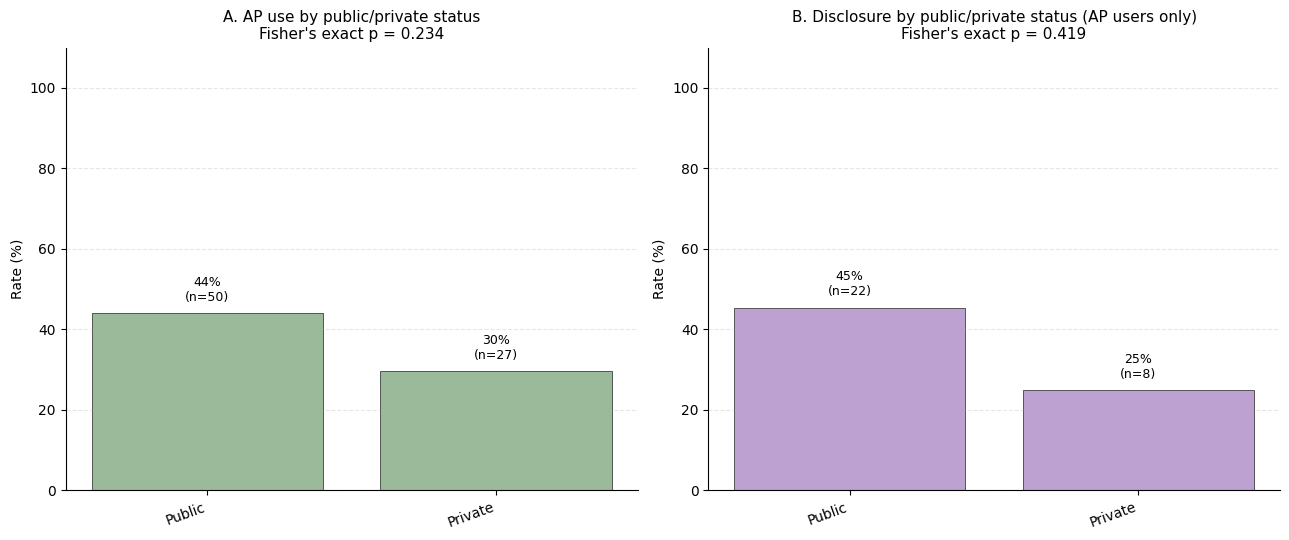

Saved /content/figure2_pubpriv_two_stage.png


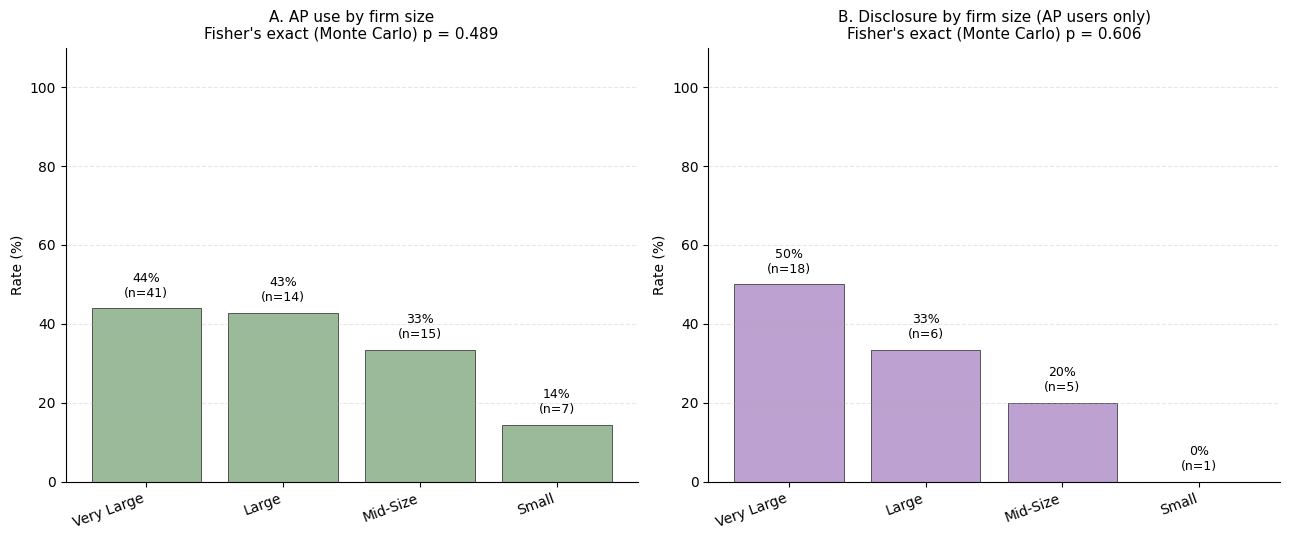

Saved /content/figure3_size_two_stage.png


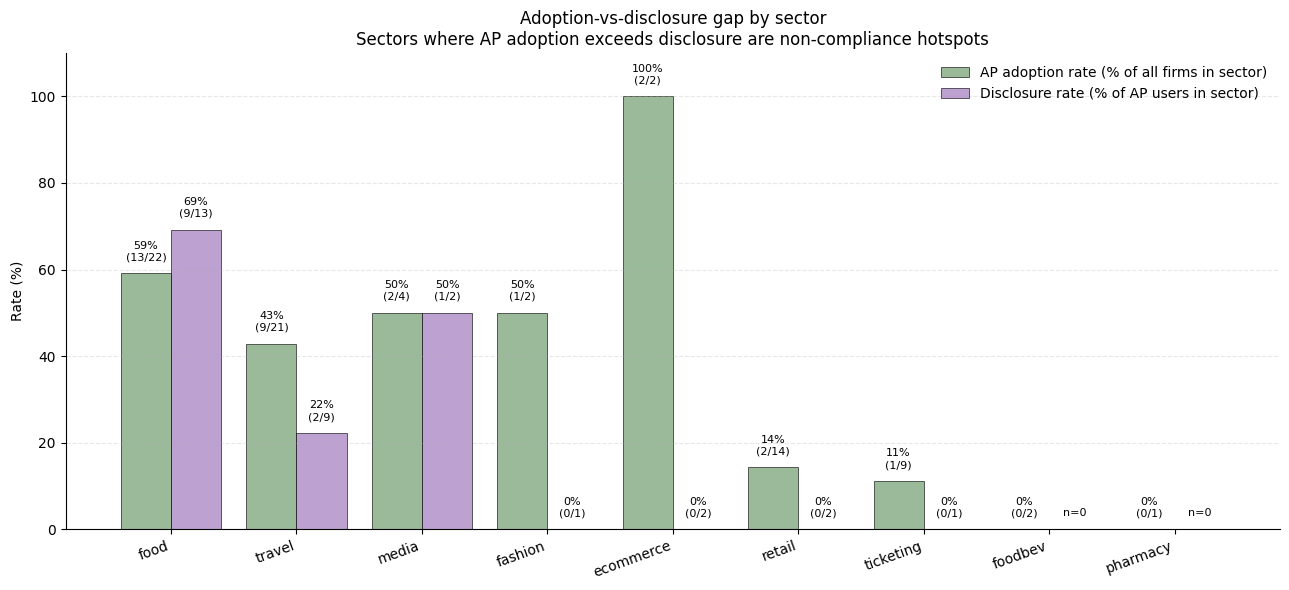

Saved /content/figure5_sector_gap.png


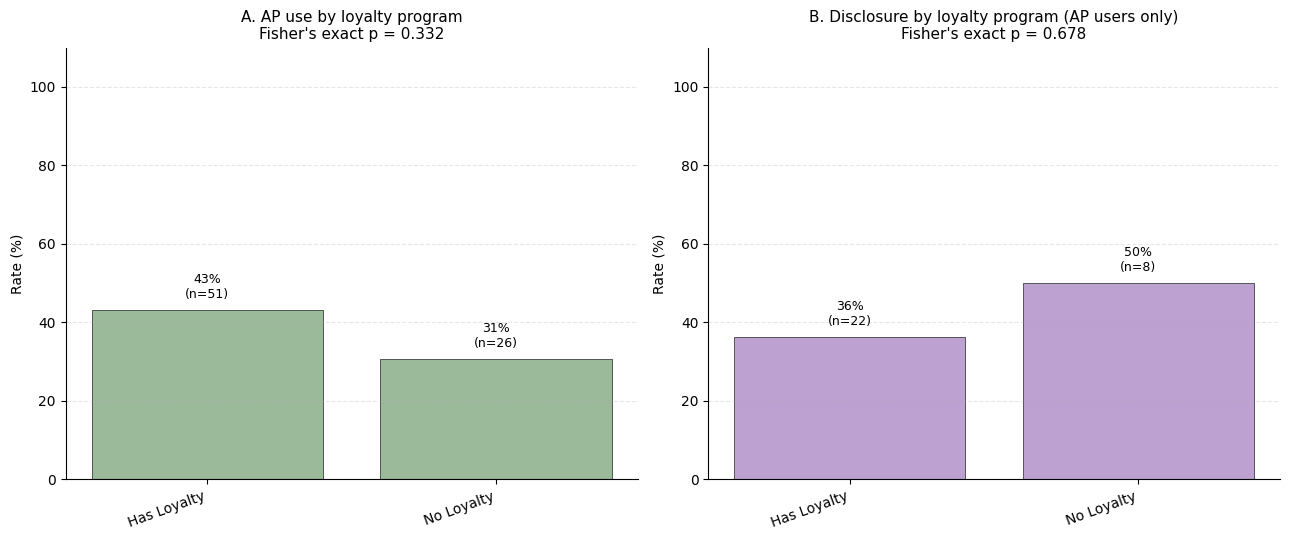

Saved /content/figure6_loyalty_two_stage.png


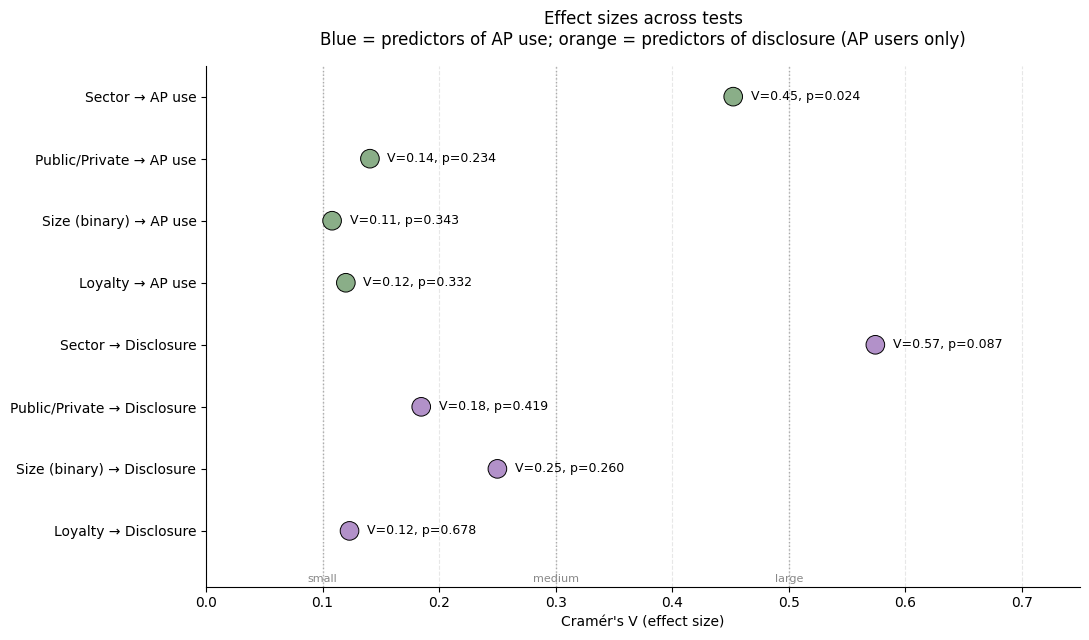

Saved /content/figure7_effect_size_forest.png


In [16]:
ADOPT_COLOR = '#8AAE88'
DISCLOSE_COLOR = '#B291C9'
GAP_COLOR = '#FEC56C'

df['public_label'] = np.where(df['public'], 'Public', 'Private')
df['loyalty_label'] = np.where(df['loyalty'], 'Has Loyalty', 'No Loyalty')

def rates_by_group(panel, group_col, outcome_col, group_order=None):
    rows = []
    groups = group_order if group_order else sorted(panel[group_col].dropna().unique())
    for g in groups:
        sub = panel[panel[group_col] == g]
        n = len(sub)
        if n == 0:
            rows.append({'group': g, 'n': 0, 'rate': 0})
            continue
        succ = sub[outcome_col].sum()
        rate = succ / n
        rows.append({'group': g, 'n': n, 'rate': rate})
    return pd.DataFrame(rows)

def plot_two_stage(predictor, group_order, title_prefix,
                   adoption_subtitle, disclosure_subtitle, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    data_a = rates_by_group(df, predictor, 'confirmed_pricing', group_order)
    ap_users = df[df['confirmed_pricing']]
    data_b = rates_by_group(ap_users, predictor, 'disclosure', group_order)

    for ax, data, color, panel_title in [
        (axes[0], data_a, ADOPT_COLOR, f'A. AP use by {title_prefix}\n{adoption_subtitle}'),
        (axes[1], data_b, DISCLOSE_COLOR, f'B. Disclosure by {title_prefix} (AP users only)\n{disclosure_subtitle}'),
    ]:
        x = np.arange(len(data))
        ax.bar(x, data['rate'] * 100, color=color, alpha=0.85,
               edgecolor='black', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(data['group'], rotation=20, ha='right')
        ax.set_ylabel('Rate (%)')
        ax.set_title(panel_title, fontsize=11)
        ax.set_ylim(0, 110)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        for i, row in data.iterrows():
            label = f"{row['rate']*100:.0f}%\n(n={row['n']})" if row['n'] > 0 else "n=0"
            ax.text(i, max(row['rate']*100, 0) + 3, label, ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {out_path}")


    # Figure 1 — Sector
sector_order = ['ecommerce', 'food', 'fashion', 'media', 'travel',
                'retail', 'ticketing', 'foodbev', 'pharmacy']
plot_two_stage(
    'sector', sector_order, 'sector',
    "Fisher's exact (Monte Carlo) p = 0.024, Cramér's V = 0.45",
    "Fisher's exact (Monte Carlo) p = 0.087, Cramér's V = 0.57",
    '/content/figure1_sector_two_stage.png',
)

# Figure 2 — Public/Private
plot_two_stage(
    'public_label', ['Public', 'Private'], 'public/private status',
    "Fisher's exact p = 0.234",
    "Fisher's exact p = 0.419",
    '/content/figure2_pubpriv_two_stage.png',
)

# Figure 3 — Size (4-level)
plot_two_stage(
    'size_bucket', ['Very Large', 'Large', 'Mid-Size', 'Small'], 'firm size',
    "Fisher's exact (Monte Carlo) p = 0.489",
    "Fisher's exact (Monte Carlo) p = 0.606",
    '/content/figure3_size_two_stage.png',
)

def plot_sector_gap(out_path):
    sectors_in_order = ['food', 'travel', 'media', 'fashion', 'ecommerce',
                        'retail', 'ticketing', 'foodbev', 'pharmacy']
    rows = []
    for s in sectors_in_order:
        n_total = (df['sector'] == s).sum()
        n_ap = df[df['sector'] == s]['confirmed_pricing'].sum()
        ap_rate = n_ap / n_total if n_total else 0
        ap_subset = df[(df['sector'] == s) & df['confirmed_pricing']]
        n_disc = ap_subset['disclosure'].sum() if len(ap_subset) else 0
        disc_rate = n_disc / n_ap if n_ap else 0
        rows.append({'sector': s, 'n_total': n_total, 'n_ap': n_ap,
                     'ap_rate': ap_rate, 'n_disc': n_disc, 'disc_rate': disc_rate})
    data = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(data))
    w = 0.4

    bars1 = ax.bar(x - w/2, data['ap_rate'] * 100, w,
                   color=ADOPT_COLOR, alpha=0.85, edgecolor='black',
                   linewidth=0.5, label='AP adoption rate (% of all firms in sector)')
    bars2 = ax.bar(x + w/2, data['disc_rate'] * 100, w,
                   color=DISCLOSE_COLOR, alpha=0.85, edgecolor='black',
                   linewidth=0.5, label='Disclosure rate (% of AP users in sector)')

    ax.set_xticks(x)
    ax.set_xticklabels(data['sector'], rotation=20, ha='right')
    ax.set_ylabel('Rate (%)')
    ax.set_title('Adoption-vs-disclosure gap by sector\n'
                 'Sectors where AP adoption exceeds disclosure are non-compliance hotspots',
                 fontsize=12)
    ax.set_ylim(0, 110)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', frameon=False)

    for i, row in data.iterrows():
        ap_label = f"{row['ap_rate']*100:.0f}%\n({row['n_ap']}/{row['n_total']})"
        ax.text(i - w/2, row['ap_rate']*100 + 3, ap_label,
                ha='center', fontsize=8)
        if row['n_ap'] > 0:
            disc_label = f"{row['disc_rate']*100:.0f}%\n({row['n_disc']}/{row['n_ap']})"
        else:
            disc_label = "n=0"
        ax.text(i + w/2, max(row['disc_rate']*100, 0) + 3, disc_label,
                ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {out_path}")


plot_sector_gap('/content/figure5_sector_gap.png')

loyalty_ap_table = pd.crosstab(df['loyalty'], df['confirmed_pricing']).values
_, p_loyalty_ap = stats.fisher_exact(loyalty_ap_table, alternative='two-sided')

ap_only = df[df['confirmed_pricing']]
loyalty_disc_table = pd.crosstab(ap_only['loyalty'], ap_only['disclosure']).values
_, p_loyalty_disc = stats.fisher_exact(loyalty_disc_table, alternative='two-sided')

plot_two_stage(
    'loyalty_label', ['Has Loyalty', 'No Loyalty'], 'loyalty program',
    f"Fisher's exact p = {p_loyalty_ap:.3f}",
    f"Fisher's exact p = {p_loyalty_disc:.3f}",
    '/content/figure6_loyalty_two_stage.png',
)

def plot_forest(out_path):
    # Compute Cramér's V for each test
    def cramers_v(table):
        chi2, _, _, _ = stats.chi2_contingency(table.values, correction=False)
        n = table.values.sum()
        r, c = table.shape
        return np.sqrt(chi2 / (n * min(r - 1, c - 1)))

    df['size_binary'] = np.where(df['size_bucket'] == 'Very Large', 'Very Large', 'Other')
    ap = df[df['confirmed_pricing']]

    tests = [
        # (label, panel, predictor_col, outcome_col, p_value_to_show)
        ("Sector → AP use", df, 'sector', 'confirmed_pricing', 0.024),
        ("Public/Private → AP use", df, 'public_label', 'confirmed_pricing', 0.234),
        ("Size (binary) → AP use", df, 'size_binary', 'confirmed_pricing', 0.343),
        ("Loyalty → AP use", df, 'loyalty_label', 'confirmed_pricing', p_loyalty_ap),
        ("Sector → Disclosure", ap, 'sector', 'disclosure', 0.087),
        ("Public/Private → Disclosure", ap, 'public_label', 'disclosure', 0.419),
        ("Size (binary) → Disclosure", ap, 'size_binary', 'disclosure', 0.260),
        ("Loyalty → Disclosure", ap, 'loyalty_label', 'disclosure', p_loyalty_disc),
    ]
    rows = []
    for label, panel, pred, out, p in tests:
        t = pd.crosstab(panel[pred], panel[out])
        v = cramers_v(t)
        rows.append({'test': label, 'V': v, 'p': p})
    forest = pd.DataFrame(rows)
    forest = forest.iloc[::-1].reset_index(drop=True)  # reverse for plotting

    fig, ax = plt.subplots(figsize=(11, 6.5))
    y = np.arange(len(forest))

    colors = ['#8AAE88' if 'AP use' in t else '#B291C9' for t in forest['test']]
    ax.scatter(forest['V'], y, s=180, c=colors, edgecolor='black',
               linewidth=0.7, zorder=3)
    for i, row in forest.iterrows():
        ax.text(row['V'] + 0.015, i, f"V={row['V']:.2f}, p={row['p']:.3f}",
                va='center', fontsize=9)

    # Effect-size benchmark lines, labels at bottom of plot
    for v_bench, label in [(0.1, 'small'), (0.3, 'medium'), (0.5, 'large')]:
        ax.axvline(v_bench, color='#aaa', linestyle=':', lw=1, zorder=1)
        ax.text(v_bench, -0.7, label, ha='center',
                fontsize=8, color='#888', va='top')

    ax.set_yticks(y)
    ax.set_yticklabels(forest['test'])
    ax.set_xlim(0, 0.75)
    ax.set_ylim(-0.9, len(forest) - 0.5)
    ax.set_xlabel("Cramér's V (effect size)")
    ax.set_title('Effect sizes across tests\n'
                 'Blue = predictors of AP use; orange = predictors of disclosure (AP users only)',
                 fontsize=12, pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {out_path}")


plot_forest('/content/figure7_effect_size_forest.png')

In [21]:
N_MC_PERMUTATIONS = 100_000
SEED = 42
df['size_binary'] = np.where(df['size_bucket'] == 'Very Large', 'Very Large', 'Other')
def cramers_v(table_array):
    #Compute Cramér's V from a contingency table (as numpy array).
    chi2, _, _, _ = stats.chi2_contingency(table_array, correction=False)
    n = table_array.sum()
    r, c = table_array.shape
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))


def monte_carlo_fisher(table_array, n_sims=N_MC_PERMUTATIONS, seed=SEED):
    #Monte Carlo Fisher's exact for r×c tables.
    obs = table_array
    n = obs.sum()
    r, c = obs.shape
    row_sums = obs.sum(axis=1)
    col_sums = obs.sum(axis=0)
    expected = np.outer(row_sums, col_sums) / n
    chi2_obs = ((obs - expected) ** 2 / expected).sum()

    rng = np.random.default_rng(seed)
    row_labels = np.repeat(np.arange(r), row_sums)
    col_template = np.repeat(np.arange(c), col_sums)

    extreme = 0
    for _ in range(n_sims):
        permuted_cols = rng.permutation(col_template)
        sim = np.zeros((r, c), dtype=int)
        np.add.at(sim, (row_labels, permuted_cols), 1)
        chi2_sim = ((sim - expected) ** 2 / expected).sum()
        if chi2_sim >= chi2_obs:
            extreme += 1

    return (extreme + 1) / (n_sims + 1)


def run_test(panel, predictor_col, outcome_col, predictor_label):
    #Run chi-square and Fisher's exact (closed-form or MC) for one predictor × outcome combination.
    table = pd.crosstab(panel[predictor_col], panel[outcome_col])
    obs = table.values
    n = obs.sum()
    r, c = obs.shape

    # Chi-square
    chi2, p_chi, _, expected = stats.chi2_contingency(obs, correction=False)
    n_below_5 = (expected < 5).sum()
    pct_below_5 = n_below_5 / expected.size * 100
    cochran_violated = (pct_below_5 > 20) or (expected.min() < 1)

    # Fisher's exact
    if r == 2 and c == 2:
        _, p_fisher = stats.fisher_exact(obs, alternative='two-sided')
        fisher_type = '2×2'
    else:
        p_fisher = monte_carlo_fisher(obs)
        fisher_type = 'MC'

    V = cramers_v(obs)

    return {
        'Predictor': predictor_label,
        'N': n,
        'Chi² p': p_chi,
        "Fisher's p": p_fisher,
        'Fisher type': fisher_type,
        "Cramér's V": V,
        'Cochran violated': f"Yes ({pct_below_5:.0f}%)" if cochran_violated else 'No',
    }

# Build the table
rows = []

# Run 1: predictors of AP use (full sample, n=77)
rows.append({'section': 'Run 1: Predictors of AP Use (n = 77)'})
for pred_col, pred_label in [
    ('size_binary', 'Size (Very Large vs Other)'),
    ('sector', 'Sector'),
    ('public', 'Public/Private'),
    ('loyalty', 'Loyalty Program'),
]:
    rows.append(run_test(df, pred_col, 'confirmed_pricing', pred_label))

# Run 2: predictors of disclosure (AP users only, n=30)
rows.append({'section': 'Run 2: Predictors of Disclosure | AP Users Only (n = 30)'})
ap_users = df[df['confirmed_pricing']]
for pred_col, pred_label in [
    ('size_binary', 'Size (Very Large vs Other)'),
    ('sector', 'Sector'),
    ('public', 'Public/Private'),
    ('loyalty', 'Loyalty Program'),
]:
    rows.append(run_test(ap_users, pred_col, 'disclosure', pred_label))

# Build the DataFrame for display
display_rows = []
for r in rows:
    if 'section' in r:
        display_rows.append({'Predictor': r['section'], 'N': '', 'Chi² p': '',
                             "Fisher's p": '', "Cramér's V": '',
                             'Cochran violated': ''})
    else:
        display_rows.append({
            'Predictor': r['Predictor'],
            'N': r['N'],
            'Chi² p': f"{r['Chi² p']:.3f}",
            "Fisher's p": f"{r['Fisher\'s p']:.3f} ({r['Fisher type']})",
            "Cramér's V": f"{r['Cramér\'s V']:.2f}",
            'Cochran violated': r['Cochran violated'],
        })

results_df = pd.DataFrame(display_rows)
print("Summary table:")
print(results_df.to_string(index=False))
print()

Summary table:
                                               Predictor  N Chi² p  Fisher's p Cramér's V Cochran violated
                    Run 1: Predictors of AP Use (n = 77)                                                  
                              Size (Very Large vs Other) 77  0.343 0.361 (2×2)       0.11               No
                                                  Sector 77  0.046  0.024 (MC)       0.45        Yes (61%)
                                          Public/Private 77  0.217 0.234 (2×2)       0.14               No
                                         Loyalty Program 77  0.293 0.332 (2×2)       0.12               No
Run 2: Predictors of Disclosure | AP Users Only (n = 30)                                                  
                              Size (Very Large vs Other) 30  0.171 0.260 (2×2)       0.25        Yes (25%)
                                                  Sector 30  0.129  0.087 (MC)       0.57        Yes (79%)
                      